### download the dataset from kagel:

In [49]:
!pip install -q Kaggle
!pip install --upgrade kaggle


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Download the datasets

In [50]:
import os
from dotenv import load_dotenv

# Load variables from .env file (located one folder up)
load_dotenv(dotenv_path="../.env")

# Set the token for Kaggle
os.environ["KAGGLE_API_TOKEN"] = os.getenv("KAGGLE_API_TOKEN")

# Download the dataset and unzip it directly into the 'data' folder
print("Downloading dataset...")
!kaggle datasets download -d anvitkumar/shopping-dataset -p ../data --unzip
print("Dataset downloaded to the 'data' folder successfully ✅")

Dataset URL: https://www.kaggle.com/datasets/anvitkumar/shopping-dataset
License(s): MIT

Dataset downloaded to the 'data' folder successfully ✅



  0%|          | 0.00/1.22M [00:00<?, ?B/s]
 82%|████████▏ | 1.00M/1.22M [00:00<00:00, 1.84MB/s]
100%|██████████| 1.22M/1.22M [00:00<00:00, 2.00MB/s]


## loading the dataset

In [51]:
import pandas as pd

# Load the combined dataset
df = pd.read_csv("../data/Combined_dataset.csv")

# Print shape
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 24)


In [52]:
df.head()

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995,58.0,"""₹3,995.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899,35.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/913...,...,"{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999,65.0,"""₹2,999.00""",INR,http://assets.myntassets.com/assets/images/176...,...,"{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
3,1376949,F Gear,Unisex Navy & Grey Printed Burner Backpack,4.4,1052,1675,52.0,"""₹1,675.00""",INR,http://assets.myntassets.com/assets/images/137...,...,"{""1_star"":33,""2_stars"":21,""3_stars"":69,""4_star...",NaN,NaN,"[{""size"":""Onesize""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
4,13939916,MYTRIDENT,Men Blue Solid Bath Robe,4.7,12,2899,17.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/pro...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""M"",""value"":""45.0in"",""value_name"":""Fr...",NaN,NaN,"[{},{},{},{},{},{},{},{},{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on IndusI...",bath-robe


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              1000 non-null   int64  
 1   title                   1000 non-null   object 
 2   product_description     1000 non-null   object 
 3   rating                  1000 non-null   float64
 4   ratings_count           1000 non-null   int64  
 5   initial_price           1000 non-null   int64  
 6   discount                879 non-null    float64
 7   final_price             1000 non-null   object 
 8   currency                1000 non-null   object 
 9   images                  1000 non-null   object 
 10  delivery_options        1000 non-null   object 
 11  product_details         1000 non-null   object 
 12  breadcrumbs             1000 non-null   object 
 13  product_specifications  1000 non-null   object 
 14  amount_of_stars         1000 non-null   o

> ### Notes this: 
 - we here find the 'final_price' is in (object) format not in (float) format.

In [54]:
df.isnull().sum()[df.isnull().sum() > 0]


discount               121
what_customers_said    573
seller_name            301
videos                 781
seller_information     301
variations             562
dtype: int64

we found there is missing data in [`discount`, `what_customers_said`, `seller_name`, `videos`, `seller_information`, `variations`].
 - and they are not that important like the others

###  Check missing values for the columns we care about

In [55]:
columns_that_matters = ['title', 'product_description', 'rating', 'initial_price', 'final_price', 'currency']
print("\nMissing values count:")
print(df[columns_that_matters].isnull().sum())

# Display the first 2 rows
df[columns_that_matters].head(2)


Missing values count:
title                  0
product_description    0
rating                 0
initial_price          0
final_price            0
currency               0
dtype: int64


,title,product_description,rating,initial_price,final_price,currency
0,Lino Perros,Women Navy Blue Solid Backpack,3.8,3995,"""₹3,995.00""",INR
1,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,2899,"""₹2,899.00""",INR


> ### Notes again : 
 - we here find the 'final_price' also contains the Indian Rupee symbol "₹3,995.00" and commas, so it needs to be cleaned up and converted to dollars & convert it into 'float'.

### Defect 1: Remove Duplicate Products
- We need to remove duplicate products based on `title` and `final_price` to prevent repeated search results.

In [56]:
before_count = len(df)

# Remove duplicates
df = df.drop_duplicates(subset=['title', 'final_price'], keep='first')
removed_duplicates = before_count - len(df)

print("--- Duplicate Check ---")
print(f"Total rows before : {before_count}")
print(f"Duplicates removed:  {removed_duplicates} 🗑️")
print(f"Total rows after  : {len(df)}")

--- Duplicate Check ---
Total rows before : 1000
Duplicates removed:  87 🗑️
Total rows after  : 913


### Defect 2: Clean and Normalize **Prices** to USD

In [57]:
df['currency'].value_counts()

currency
INR    913
Name: count, dtype: int64

In [58]:
import re

def clean_and_convert_price(price_str, currency):
    price_str = str(price_str).strip()
    # Remove everything except digits and dot
    price_clean = re.sub(r'[^\d.]', '', price_str)
    price_val = float(price_clean) if price_clean else 0.0
    
    # Convert INR (₹) to USD (1 INR ~ 0.012 USD)
    if 'INR' in str(currency) or '₹' in price_str:
        price_val = price_val * 0.012
        
    return round(price_val, 2)

In [ ]:
df['final_price_usd'] = df.apply(lambda row: clean_and_convert_price(row['final_price'], row['currency']), axis=1)
df['initial_price_usd'] = df.apply(lambda row: clean_and_convert_price(row['initial_price'], row['currency']), axis=1)
df['currency'] = 'USD'

##### Show Before & After for "**prices**"

In [60]:
print("--- Price Cleaning Check ---")
print("Before:", df['final_price'].head(3).tolist())
print("After (USD):", df['final_price_usd'].head(3).tolist())

--- Price Cleaning Check ---
Before: ['"₹3,995.00"', '"₹2,899.00"', '"₹2,999.00"']
After (USD): [47.94, 34.79, 35.99]


### Defect 3: Handle specific missing values without dropping rows

In [61]:
# fills we need : 
df['discount'] = df['discount'].fillna(0.0)
df['what_customers_said'] = df['what_customers_said'].fillna('No reviews available')
df['seller_name'] = df['seller_name'].fillna('Unknown Seller')
df['seller_information'] = df['seller_information'].fillna('No information available')
df['variations'] = df['variations'].fillna('Standard')
df['videos'] = df['videos'].fillna('sorry, no videos available')

# Safety fallback:
df['product_description'] = df['product_description'].fillna(df['title'])
df['rating'] = df['rating'].fillna(0.0)
df['ratings_count'] = df['ratings_count'].fillna(0)
df['images'] = df['images'].fillna('https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQxmLd-lKZathn7_IQch_8EtHCMJ7HxOUGaS5L02rc8_A&s=10')


##### Show Before & After Handle missing values

In [62]:
print("\n--- Missing Values Remaining ---")
print(df[['what_customers_said','discount', 'seller_name']].isnull().sum())


--- Missing Values Remaining ---
what_customers_said    0
discount               0
seller_name            0
dtype: int64


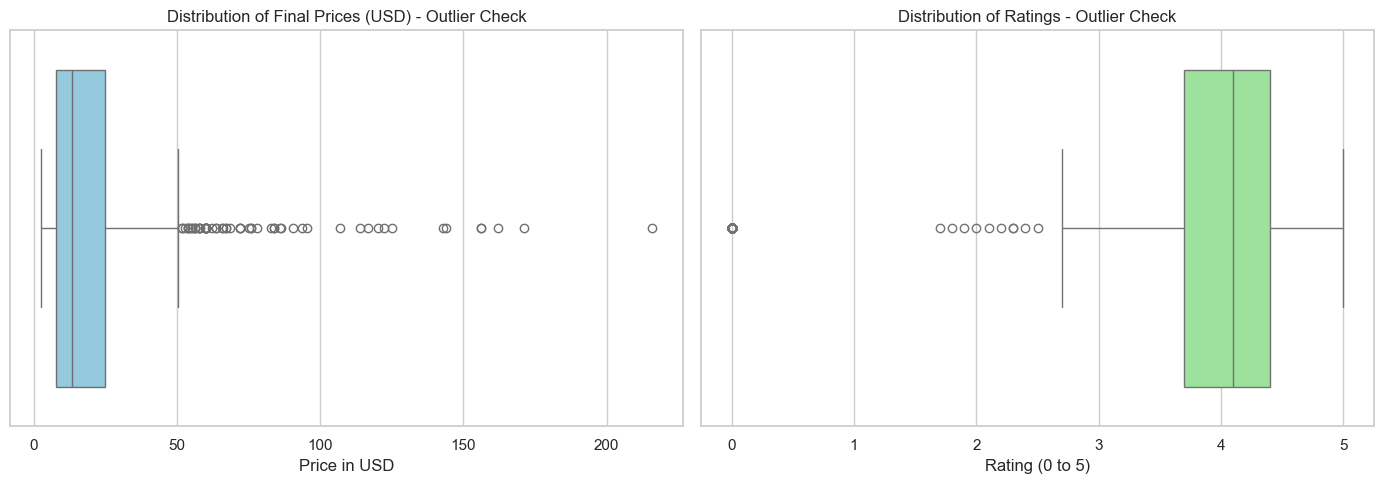

📊 Plot saved to ../data/outliers_check.png


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# 1. Boxplot for Prices (Check for expensive outliers)
plt.subplot(1, 2, 1)
sns.boxplot(x=df['final_price_usd'], color='skyblue')
plt.title('Distribution of Final Prices (USD) - Outlier Check')
plt.xlabel('Price in USD')

# 2. Boxplot for Ratings (Check for odd ratings)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['rating'], color='lightgreen')
plt.title('Distribution of Ratings - Outlier Check')
plt.xlabel('Rating (0 to 5)')

plt.tight_layout()

# Save the plot so I can view it!
plot_path = "../data/outliers_check.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📊 Plot saved to {plot_path}")

> ## Notes :
- **Prices:** Outliers up to $200+ are valid and represent premium products, so we will keep them.
- **Ratings:** Low ratings (0–2) are also valid and useful for helping the chatbot avoid recommending poor products.

---

### Defect 3: Validate and Clean Ratings & Counts
- Ratings must strictly be numbers between `0.0` and `5.0`.

In [64]:
print(f"\n>>   Min Rating: {df['rating'].min()}, Max Rating: {df['rating'].max()}")


>>   Min Rating: 0.0, Max Rating: 5.0


In [65]:
# Clip ratings to 0-5 range for future safety:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(0.0)
df['rating'] = df['rating'].clip(0.0, 5.0)
print("================= Show Ratings Clean Summary =================")
print(f"\n>>   Min Rating: {df['rating'].min()}, Max Rating: {df['rating'].max()}")

================= Show Ratings Clean Summary =================

>>   Min Rating: 0.0, Max Rating: 5.0


### Defect 4: Clean Text Columns (HTML tags, special characters & extra spaces)
- Strip HTML tags, redundant whitespaces, and odd special characters from all key text columns.

- The text columns (`title`, `product_description`, `what_customers_said`, `product_specifications`) might contain raw HTML tags or excessive whitespaces.
- We need to strip these to ensure clean text for the RAG search and LLM models.

In [66]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'<[^>]+>', '', text)             # Remove HTML tags (like <br>, <b>)
    text = re.sub(r'[^\w\s.,!?;:\-\'\"()/&%$#@+★☆●]', '', text)
    text = ' '.join(text.split())                # Remove extra spaces and newlines
    return text

text_columns = ['title', 'product_description', 'what_customers_said', 'product_specifications', 'category']

print("--- Text Cleaning Check (Row 46) ---")
print("Before:", df[text_columns].iloc[46].to_dict())

# Apply Cleaning
for col in text_columns:
    df[col] = df[col].apply(clean_text)

print("\nAfter: ", df[text_columns].iloc[46].to_dict())

--- Text Cleaning Check (Row 46) ---
Before: {'title': 'Zoiro', 'product_description': 'Men Pack Of 2 Anti-Bacterial Basic Briefs', 'what_customers_said': '[{"percentage":"100","value_name":"Fit, Just Right"}]', 'product_specifications': '[{"specification_name":"Assorted","specification_value":"No"},{"specification_name":"Character","specification_value":"NA"},{"specification_name":"Fabric","specification_value":"Cotton"},{"specification_name":"Fabric 2","specification_value":"Elastane"},{"specification_name":"Features","specification_value":"NA"},{"specification_name":"Knit or Woven","specification_value":"Knitted"},{"specification_name":"Multipack Set","specification_value":"2"},{"specification_name":"Pattern","specification_value":"Solid"},{"specification_name":"Print or Pattern Type","specification_value":"Solid"},{"specification_name":"Style","specification_value":"NA"},{"specification_name":"Sustainable","specification_value":"Regular"},{"specification_name":"Type","specification

### Drop original prices & Export Clean Data
- Now that we have `final_price_usd` and `initial_price_usd`, we can drop the messy string columns.
- Finally, save the clean dataset to `data/products_clean.csv`.

In [68]:
df['initial_price'] = df['initial_price_usd']
df['final_price'] = df['final_price_usd']

# Drop the new price columns
df = df.drop(columns=['initial_price_usd', 'final_price_usd'])

# Save to CSV
clean_csv_path = "../data/products_clean.csv"
df.to_csv(clean_csv_path, index=False)

print(f"✅ Clean data saved successfully to {clean_csv_path}")
print("Final Shape:", df.shape)

✅ Clean data saved successfully to ../data/products_clean.csv
Final Shape: (913, 25)
